# JetClass dataset size vs $\eta_0$ transfer

Read-only analysis of JetClass pretrain LR scans at three train-set sizes. **No training in this notebook.**

Each curve is the metric **after 1 epoch** (Lightning `epoch=0`), even when a job later ran longer. Color is architecture; marker / linestyle is dataset size. All dataset sizes share a panel. $\eta_0 \in \{0.01, 0.05, 0.1, 0.25, 0.5, 1, 2.5\}$.

Width transfer at fixed $n_\mathrm{train}$ is much stronger than transfer across dataset size. One epoch at 100k is a few hundred steps; one epoch at 5M is $\sim 50\times$ more compute, so the 100k LR optimum is not a proxy for the large-data run.

| Architecture | Color |
|---|---|
| $(L,D,h)=(4,256,8)$ | smaller model |
| $(L,D,h)=(4,512,16)$ | larger model |


In [30]:
from __future__ import annotations

from pathlib import Path
import importlib
import sys

import pandas as pd

REPO = Path("../..").resolve()
sys.path.insert(0, str(REPO / "src"))

import cpen.utils.transfer_plots as transfer_plots
importlib.reload(transfer_plots)

from cpen.utils.transfer_plots import (
    JETCLASS_OUT_ROOT,
    JETCLASS_SLURM_DIRS,
    JobSpec,
    TransferStudy,
    job_status_table,
    load_jobs,
    metrics_at_epoch,
    setup_mpl_style,
)

setup_mpl_style()
FIG_DIR = REPO / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_ROOT = JETCLASS_OUT_ROOT
SLURM_DIRS = JETCLASS_SLURM_DIRS
print("transfer_plots:", transfer_plots.__file__)
print("OUT_ROOT =", OUT_ROOT)
print("FIG_DIR  =", FIG_DIR)


transfer_plots: /home/jdezoort/coupled-particle-edge-networks/src/cpen/utils/transfer_plots.py
OUT_ROOT = /scratch/gpfs/BHANIN/jdezoort/cpen_runs/jetclass_runs/jetclass_output/adam/sweep_lr
FIG_DIR  = /home/jdezoort/coupled-particle-edge-networks/notebooks/figures


## Hardcoded Slurm jobs

Array tasks `JOBID_0`. Parquets live under `jetclass_runs/jetclass_output/adam/sweep_lr`; logs in `scans/jets/slurm-<job_id>.out`.
The `512` in the original table is **batch size**. Role is the train-set size. \(\eta_0 \in \{0.01, 0.05, 0.1, 0.25, 0.5, 1, 2.5\}\).

Retried holes: 100k $D{=}256$ $\eta_0\in\{0.05,0.1,0.25,0.5\}$ are `13653204–13653242`; 5M $D{=}512$ $\eta_0{=}0.01$ is `13653255`.


In [31]:
JOBS_100K = [
    JobSpec("13652066_0", "100k", r"η0=0.01, L=4, D=256, h=8, bs=512"),
    JobSpec("13653204_0", "100k", r"η0=0.05, L=4, D=256, h=8, bs=512"),
    JobSpec("13653205_0", "100k", r"η0=0.1,  L=4, D=256, h=8, bs=512"),
    JobSpec("13653206_0", "100k", r"η0=0.25, L=4, D=256, h=8, bs=512"),
    JobSpec("13653242_0", "100k", r"η0=0.5,  L=4, D=256, h=8, bs=512"),
    JobSpec("13651074_0", "100k", r"η0=1,    L=4, D=256, h=8, bs=512"),
    JobSpec("13652075_0", "100k", r"η0=2.5,  L=4, D=256, h=8, bs=512"),
    JobSpec("13652076_0", "100k", r"η0=0.01, L=4, D=512, h=16, bs=512"),
    JobSpec("13650905_0", "100k", r"η0=0.05, L=4, D=512, h=16, bs=512"),
    JobSpec("13650909_0", "100k", r"η0=0.1,  L=4, D=512, h=16, bs=512"),
    JobSpec("13650932_0", "100k", r"η0=0.25, L=4, D=512, h=16, bs=512"),
    JobSpec("13650933_0", "100k", r"η0=0.5,  L=4, D=512, h=16, bs=512"),
    JobSpec("13650951_0", "100k", r"η0=1,    L=4, D=512, h=16, bs=512"),
    JobSpec("13652097_0", "100k", r"η0=2.5,  L=4, D=512, h=16, bs=512"),
]

JOBS_1M = [
    JobSpec("13652135_0", "1M", r"η0=0.01, L=4, D=256, h=8, bs=512"),
    JobSpec("13635052_0", "1M", r"η0=0.05, L=4, D=256, h=8, bs=512"),
    JobSpec("13629822_0", "1M", r"η0=0.1,  L=4, D=256, h=8, bs=512"),
    JobSpec("13629834_0", "1M", r"η0=0.25, L=4, D=256, h=8, bs=512"),
    JobSpec("13629835_0", "1M", r"η0=0.5,  L=4, D=256, h=8, bs=512"),
    JobSpec("13635042_0", "1M", r"η0=1,    L=4, D=256, h=8, bs=512"),
    JobSpec("13652144_0", "1M", r"η0=2.5,  L=4, D=256, h=8, bs=512"),
    JobSpec("13652111_0", "1M", r"η0=0.01, L=4, D=512, h=16, bs=512"),
    JobSpec("13636491_0", "1M", r"η0=0.05, L=4, D=512, h=16, bs=512"),
    JobSpec("13636503_0", "1M", r"η0=0.1,  L=4, D=512, h=16, bs=512"),
    JobSpec("13637294_0", "1M", r"η0=0.25, L=4, D=512, h=16, bs=512"),
    JobSpec("13637295_0", "1M", r"η0=0.5,  L=4, D=512, h=16, bs=512"),
    JobSpec("13637304_0", "1M", r"η0=1,    L=4, D=512, h=16, bs=512"),
    JobSpec("13652101_0", "1M", r"η0=2.5,  L=4, D=512, h=16, bs=512"),
]

JOBS_5M = [
    JobSpec("13652156_0", "5M", r"η0=0.01, L=4, D=256, h=8, bs=512"),
    JobSpec("13637344_0", "5M", r"η0=0.05, L=4, D=256, h=8, bs=512"),
    JobSpec("13637350_0", "5M", r"η0=0.1,  L=4, D=256, h=8, bs=512"),
    JobSpec("13637356_0", "5M", r"η0=0.25, L=4, D=256, h=8, bs=512"),
    JobSpec("13637358_0", "5M", r"η0=0.5,  L=4, D=256, h=8, bs=512"),
    JobSpec("13637365_0", "5M", r"η0=1,    L=4, D=256, h=8, bs=512"),
    JobSpec("13652161_0", "5M", r"η0=2.5,  L=4, D=256, h=8, bs=512"),
    JobSpec("13653255_0", "5M", r"η0=0.01, L=4, D=512, h=16, bs=512"),
    JobSpec("13637370_0", "5M", r"η0=0.05, L=4, D=512, h=16, bs=512"),
    JobSpec("13637376_0", "5M", r"η0=0.1,  L=4, D=512, h=16, bs=512"),
    JobSpec("13637378_0", "5M", r"η0=0.25, L=4, D=512, h=16, bs=512"),
    JobSpec("13637383_0", "5M", r"η0=0.5,  L=4, D=512, h=16, bs=512"),
    JobSpec("13637385_0", "5M", r"η0=1,    L=4, D=512, h=16, bs=512"),
    JobSpec("13652170_0", "5M", r"η0=2.5,  L=4, D=512, h=16, bs=512"),
]

JOBS = JOBS_100K + JOBS_1M + JOBS_5M
for spec in JOBS:
    print(f"{spec.job_id:14s}  {spec.role:4s}  {spec.note}")


13652066_0      100k  η0=0.01, L=4, D=256, h=8, bs=512
13653204_0      100k  η0=0.05, L=4, D=256, h=8, bs=512
13653205_0      100k  η0=0.1,  L=4, D=256, h=8, bs=512
13653206_0      100k  η0=0.25, L=4, D=256, h=8, bs=512
13653242_0      100k  η0=0.5,  L=4, D=256, h=8, bs=512
13651074_0      100k  η0=1,    L=4, D=256, h=8, bs=512
13652075_0      100k  η0=2.5,  L=4, D=256, h=8, bs=512
13652076_0      100k  η0=0.01, L=4, D=512, h=16, bs=512
13650905_0      100k  η0=0.05, L=4, D=512, h=16, bs=512
13650909_0      100k  η0=0.1,  L=4, D=512, h=16, bs=512
13650932_0      100k  η0=0.25, L=4, D=512, h=16, bs=512
13650933_0      100k  η0=0.5,  L=4, D=512, h=16, bs=512
13650951_0      100k  η0=1,    L=4, D=512, h=16, bs=512
13652097_0      100k  η0=2.5,  L=4, D=512, h=16, bs=512
13652135_0      1M    η0=0.01, L=4, D=256, h=8, bs=512
13635052_0      1M    η0=0.05, L=4, D=256, h=8, bs=512
13629822_0      1M    η0=0.1,  L=4, D=256, h=8, bs=512
13629834_0      1M    η0=0.25, L=4, D=256, h=8, bs=512
136

In [32]:
df = load_jobs(JOBS, out_root=OUT_ROOT, slurm_dirs=SLURM_DIRS)
status = job_status_table(JOBS, df, out_root=OUT_ROOT, slurm_dirs=SLURM_DIRS)
display(status)
print(f"loaded {0 if df.empty else df['job_id'].nunique()} / {len(JOBS)} jobs")
if df.empty:
    raise RuntimeError("No JetClass parquets loaded yet.")
study = TransferStudy(
    df,
    JOBS,
    out_root=OUT_ROOT,
    slurm_dirs=SLURM_DIRS,
    fig_dir=FIG_DIR,
)


[ok] 13652066_0: η0=0.01  L=4  D=256  h=8  rows=1
[ok] 13653204_0: η0=0.05  L=4  D=256  h=8  rows=1
[ok] 13653205_0: η0=0.1  L=4  D=256  h=8  rows=1
[ok] 13653206_0: η0=0.25  L=4  D=256  h=8  rows=1
[ok] 13653242_0: η0=0.5  L=4  D=256  h=8  rows=1
[ok] 13651074_0: η0=1  L=4  D=256  h=8  rows=1
[ok] 13652075_0: η0=2.5  L=4  D=256  h=8  rows=1
[ok] 13652076_0: η0=0.01  L=4  D=512  h=16  rows=1
[ok] 13650905_0: η0=0.05  L=4  D=512  h=16  rows=1
[ok] 13650909_0: η0=0.1  L=4  D=512  h=16  rows=1
[ok] 13650932_0: η0=0.25  L=4  D=512  h=16  rows=1
[ok] 13650933_0: η0=0.5  L=4  D=512  h=16  rows=1
[ok] 13650951_0: η0=1  L=4  D=512  h=16  rows=1
[ok] 13652097_0: η0=2.5  L=4  D=512  h=16  rows=1
[ok] 13652135_0: η0=0.01  L=4  D=256  h=8  rows=5
[ok] 13635052_0: η0=0.05  L=4  D=256  h=8  rows=29
[ok] 13629822_0: η0=0.1  L=4  D=256  h=8  rows=29
[ok] 13629834_0: η0=0.25  L=4  D=256  h=8  rows=29
[ok] 13629835_0: η0=0.5  L=4  D=256  h=8  rows=29
[ok] 13635042_0: η0=1  L=4  D=256  h=8  rows=29
[ok] 

,job_id,role,note,slurm_log,run_name,parquet,loaded
0,13652066_0,100k,"η0=0.01, L=4, D=256, h=8, bs=512",True,capen-llama_4_256_0p01_ln_op-incidence_onorm-d...,True,True
1,13653204_0,100k,"η0=0.05, L=4, D=256, h=8, bs=512",True,capen-llama_4_256_0p05_ln_op-incidence_onorm-d...,True,True
2,13653205_0,100k,"η0=0.1, L=4, D=256, h=8, bs=512",True,capen-llama_4_256_0p1_ln_op-incidence_onorm-de...,True,True
3,13653206_0,100k,"η0=0.25, L=4, D=256, h=8, bs=512",True,capen-llama_4_256_0p25_ln_op-incidence_onorm-d...,True,True
4,13653242_0,100k,"η0=0.5, L=4, D=256, h=8, bs=512",True,capen-llama_4_256_0p5_ln_op-incidence_onorm-de...,True,True
5,13651074_0,100k,"η0=1, L=4, D=256, h=8, bs=512",True,capen-llama_4_256_1_ln_op-incidence_onorm-degr...,True,True
6,13652075_0,100k,"η0=2.5, L=4, D=256, h=8, bs=512",True,capen-llama_4_256_2p5_ln_op-incidence_onorm-de...,True,True
7,13652076_0,100k,"η0=0.01, L=4, D=512, h=16, bs=512",True,capen-llama_4_512_0p01_ln_op-incidence_onorm-d...,True,True
8,13650905_0,100k,"η0=0.05, L=4, D=512, h=16, bs=512",True,capen-llama_4_512_0p05_ln_op-incidence_onorm-d...,True,True
9,13650909_0,100k,"η0=0.1, L=4, D=512, h=16, bs=512",True,capen-llama_4_512_0p1_ln_op-incidence_onorm-de...,True,True


loaded 42 / 42 jobs


## Metrics after 1 epoch

Lightning logs the first completed epoch as `epoch=0`. Longer runs (5M often has a second epoch; some 1M runs have five) are sliced here, not min/max over the full trajectory.


In [33]:
epoch1 = metrics_at_epoch(study.df, epoch=0)
cols = [
    c
    for c in (
        "job_id",
        "role",
        "n_train",
        "depth",
        "width",
        "heads",
        "eta_0",
        "epoch",
        "epochs",
        "train_loss",
        "val_acc",
        "val_roc_auc",
        "val_bg_rejection",
    )
    if c in epoch1.columns
]
display(epoch1[cols])


,job_id,role,n_train,depth,width,heads,eta_0,epoch,epochs,train_loss,val_acc,val_roc_auc,val_bg_rejection
0,13652066_0,100k,100000,4,256,8,0.01,0,1,2.260312,0.232516,0.716781,7.635934
1,13653204_0,100k,100000,4,256,8,0.05,0,1,2.027264,0.359748,0.808333,24.737835
2,13653205_0,100k,100000,4,256,8,0.10,0,1,1.901996,0.382868,0.826091,31.558371
3,13653206_0,100k,100000,4,256,8,0.25,0,1,1.820510,0.407736,0.844662,45.696022
4,13653242_0,100k,100000,4,256,8,0.50,0,1,1.852579,0.411916,0.843693,37.657578
5,13651074_0,100k,100000,4,256,8,1.00,0,1,1.973579,0.380344,0.828180,17.945105
6,13652075_0,100k,100000,4,256,8,2.50,0,1,2.783291,0.315060,0.786050,12.821642
7,13652076_0,100k,100000,4,512,16,0.01,0,1,2.262059,0.236456,0.710111,8.452806
8,13650905_0,100k,100000,4,512,16,0.05,0,1,2.032070,0.359760,0.808675,26.139200
9,13650909_0,100k,100000,4,512,16,0.10,0,1,1.903087,0.405996,0.836599,40.028893


saved /home/jdezoort/coupled-particle-edge-networks/notebooks/figures/jetclass_dataset_size_lr_epoch1.pdf
saved /home/jdezoort/coupled-particle-edge-networks/notebooks/figures/jetclass_dataset_size_lr_epoch1.png


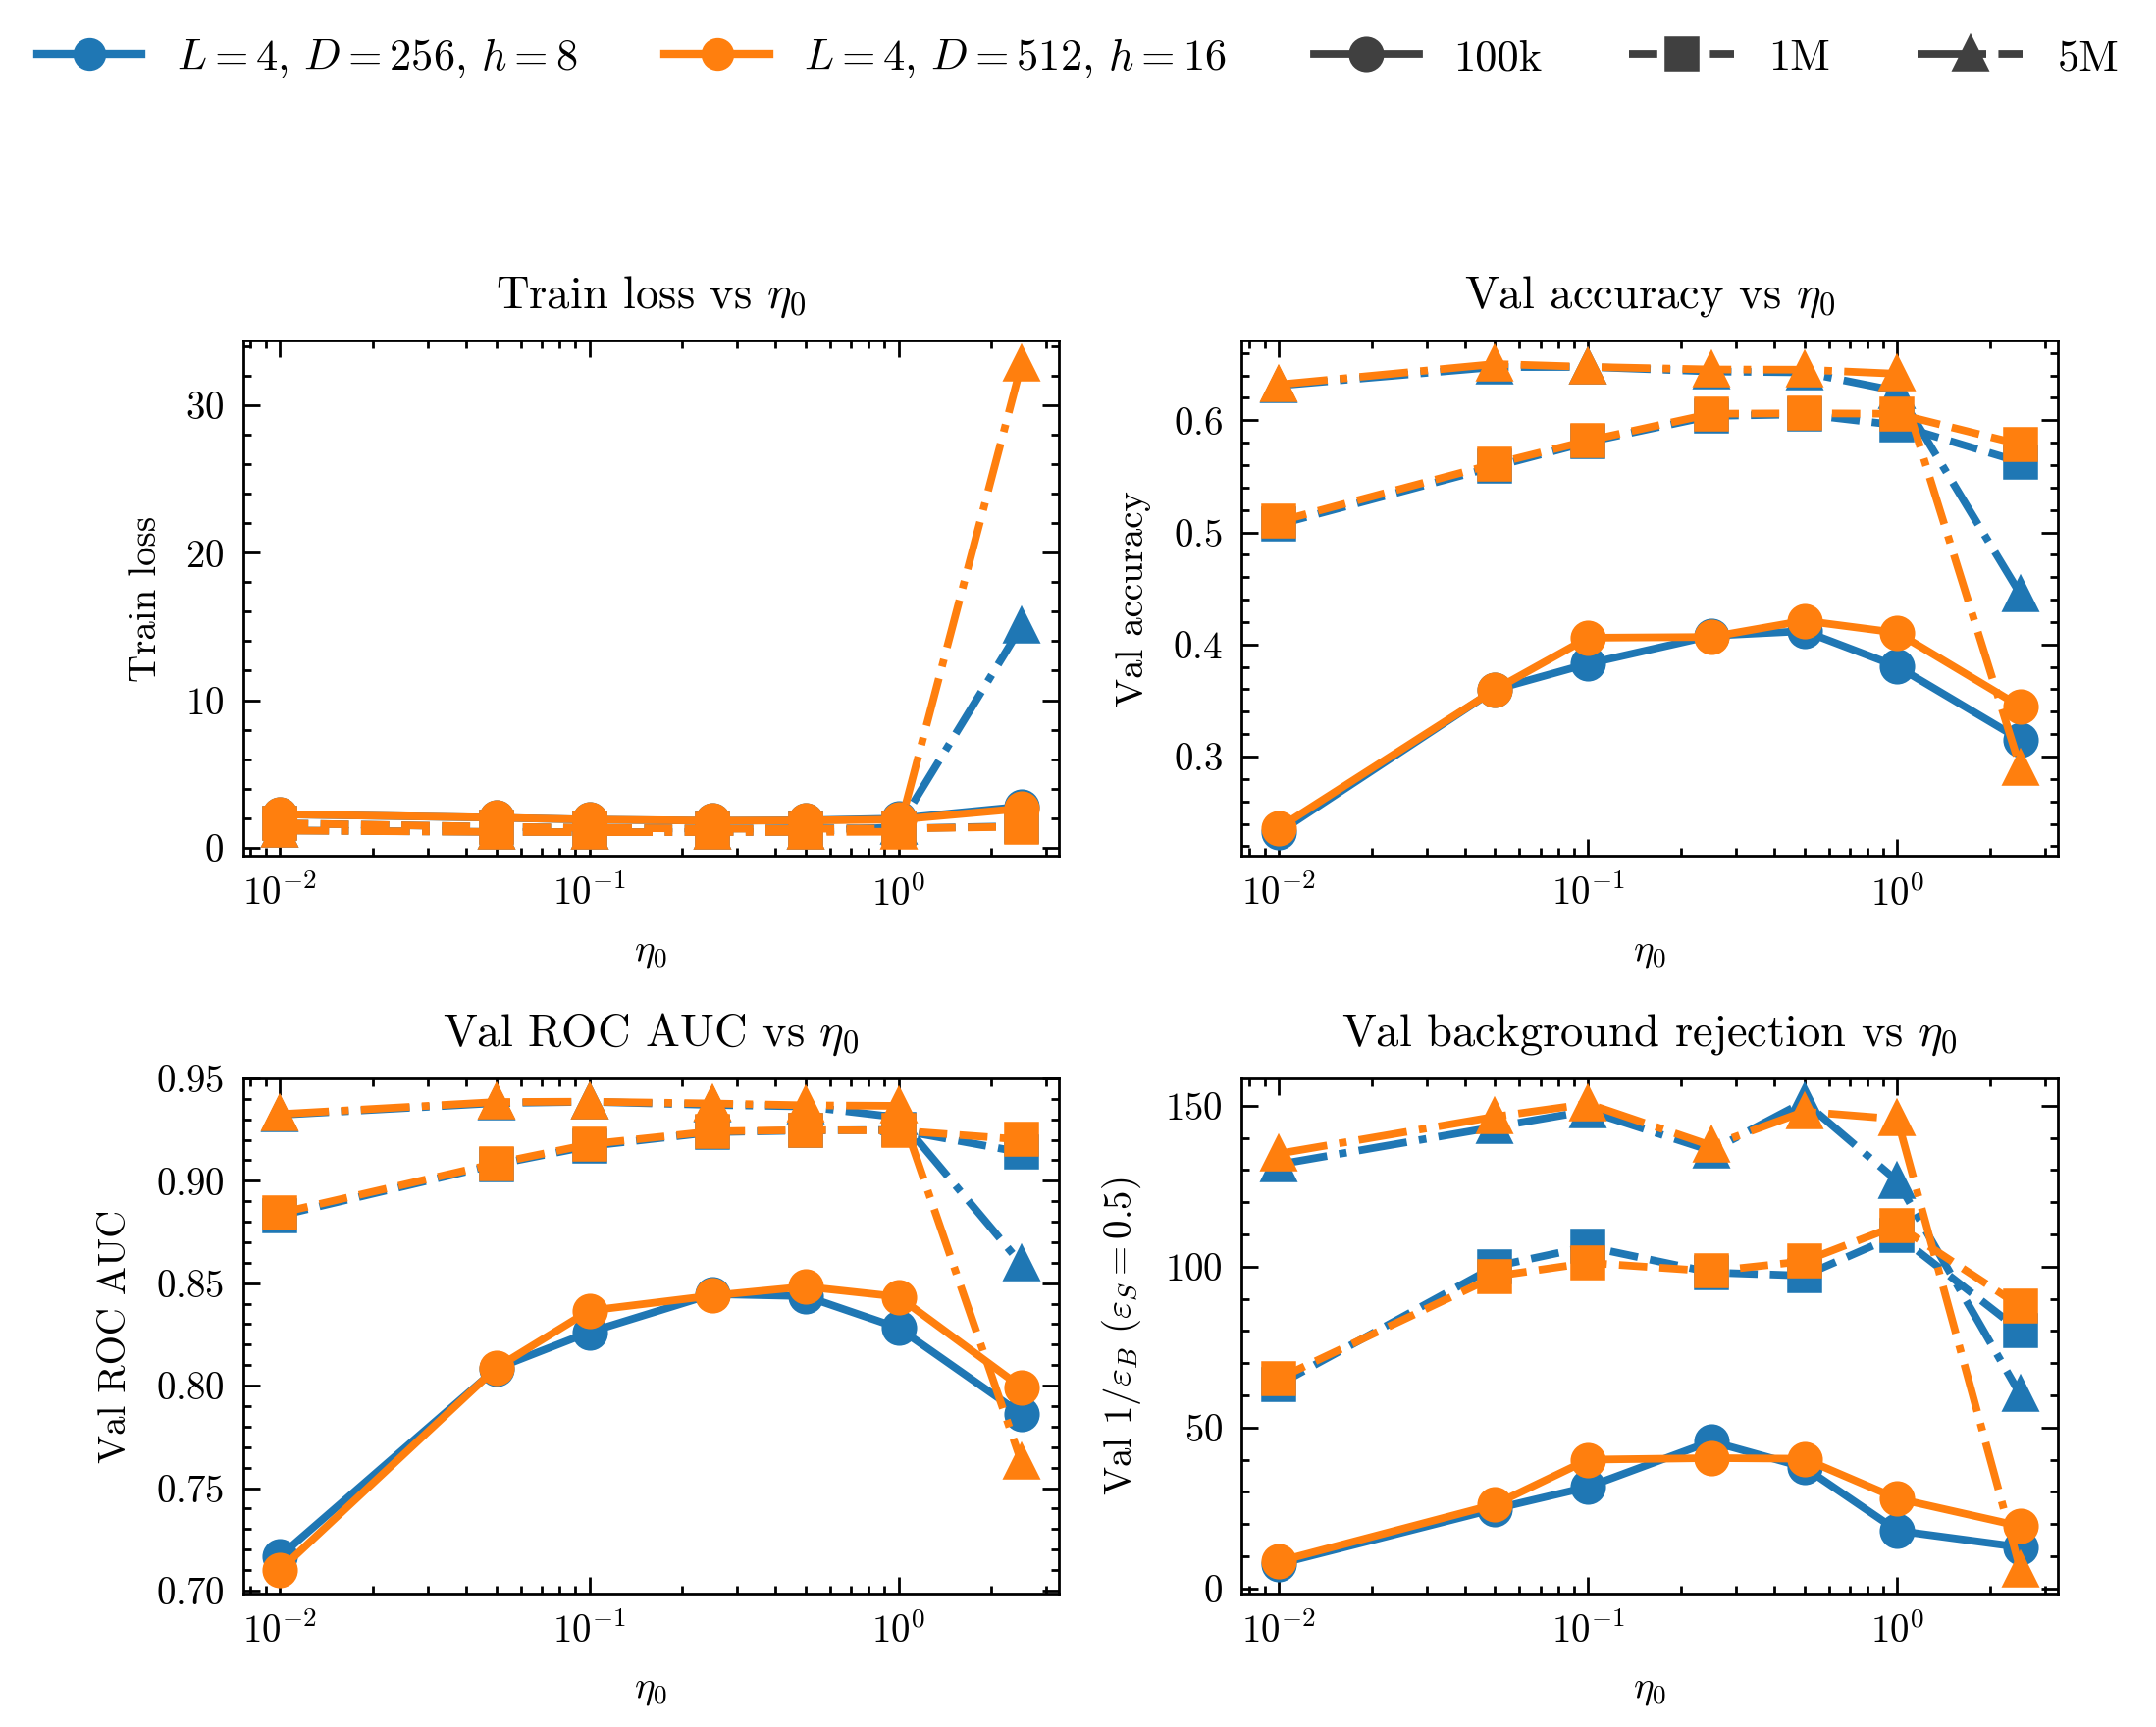

In [36]:
fig = study.plot_dataset_size_lr(
    epoch=0,
    stem="jetclass_dataset_size_lr_epoch1",
    show=True,
)


In [35]:
## Best $\eta_0$ after 1 epoch

Argmax of val ROC / argmin of train loss per $(n_\mathrm{train}, D)$. Missing $\eta_0$ values are skipped, so 100k $D{=}256$ is only $\{0.01, 1\}$ until those jobs are rerun.


SyntaxError: invalid syntax (2138921393.py, line 3)

In [ ]:
def _best_eta(frame, col, how="max"):
    rows = []
    for (n_train, width), g in frame.groupby(["n_train", "width"], sort=True):
        idx = g[col].idxmax() if how == "max" else g[col].idxmin()
        r = g.loc[idx]
        rows.append(
            {
                "n_train": int(n_train),
                "width": int(width),
                "best_eta_0": r["eta_0"],
                col: r[col],
                "n_etas": len(g),
            }
        )
    return pd.DataFrame(rows)

print("val ROC")
display(_best_eta(epoch1, "val_roc_auc", "max"))
print("train loss")
display(_best_eta(epoch1, "train_loss", "min"))
